IMPORTACION DE LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString
from shapely.ops import unary_union

plt.style.use("seaborn-v0_8")

CARGO LOS DATOS YA PROCESADOS Y PREPARO COLUMNAS CLAVES

In [2]:
df = pd.read_csv("/Users/cgsos/Documents/Cuarto/TFG/FLICKR/datos/processed/fotos_canarias.csv")

df = df.dropna(subset=["latitude", "longitude"]).copy()
df["datetaken"] = pd.to_datetime(df["datetaken"], errors="coerce")

df.shape

(95581, 34)

FILTRO DE PRECISIÓN GEOGRÁFICA + ELIMINACIÓN DE DUPLICADOS (PARA ELIMINAR RUIDO)

In [3]:
df = df[df["accuracy"].fillna(0) >= 15].copy()

df = df.drop_duplicates(subset=["owner", "latitude", "longitude", "datetaken"])

df.shape

(93146, 34)

ASIGNO CADA ISLA DE FORMA ROBUSTA A PARTIR DEL CALCULO DE SUS CENTROIDES

In [4]:
centroides = (
    df.groupby("isla")[["latitude", "longitude"]]
      .median()
      .to_dict("index")
)

def asignar_isla_por_centroides(lat, lon, centroides):
    best, dmin = None, 1e9
    for isla, coords in centroides.items():
        ilat, ilon = coords["latitude"], coords["longitude"]
        d = (lat - ilat)**2 + (lon - ilon)**2
        if d < dmin:
            best, dmin = isla, d
    return best

df["isla_fix"] = df.apply(
    lambda r: r["isla"] if pd.notna(r["isla"]) else asignar_isla_por_centroides(r.latitude, r.longitude, centroides),
    axis=1
)
df["isla_fix"].value_counts()

isla_fix
Lanzarote        26980
Tenerife         23571
Gran Canaria     18515
La Palma         10803
Fuerteventura     6580
La Gomera         4884
El Hierro         1813
Name: count, dtype: int64

ITERO UN GRÁFICO POR ISLA PARA DETERMINAR LOS EPS CORRECTOS


Isla: El Hierro


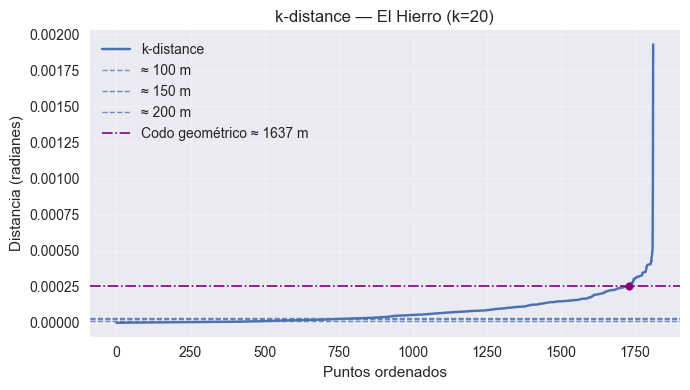


Isla: Fuerteventura


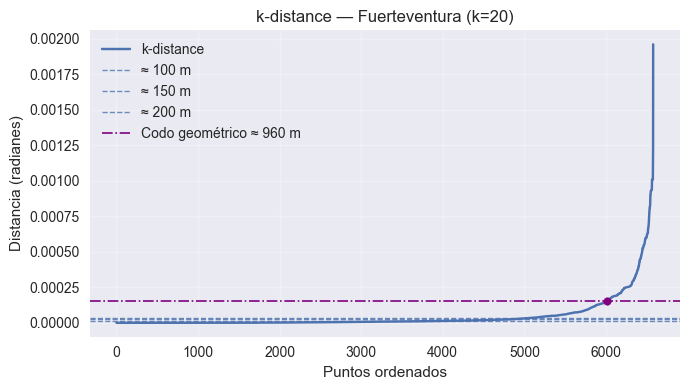


Isla: Gran Canaria


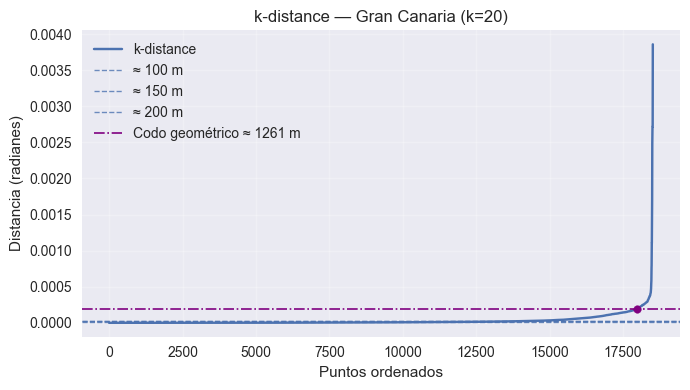


Isla: La Gomera


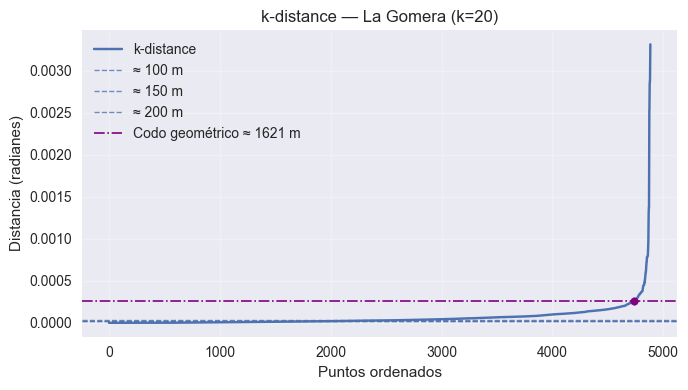


Isla: La Palma


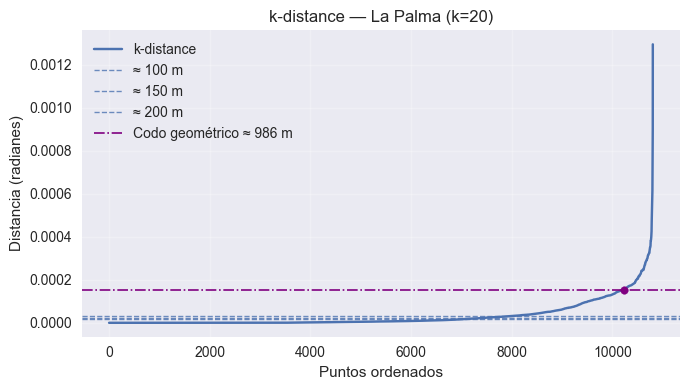


Isla: Lanzarote


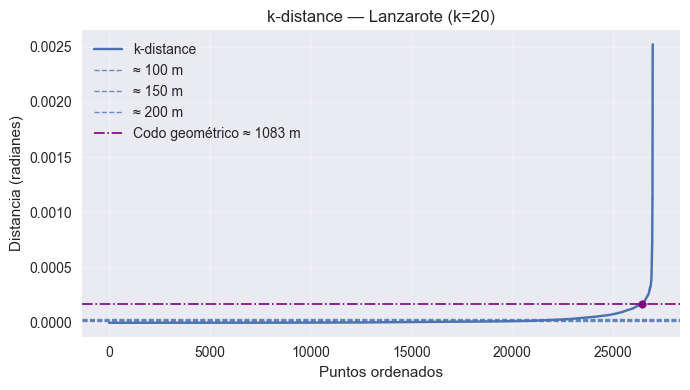


Isla: Tenerife


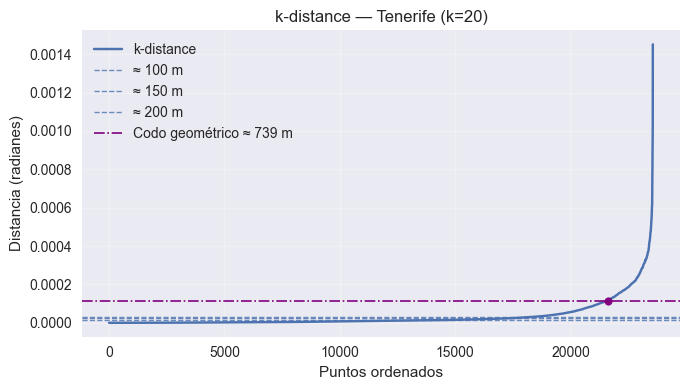

In [5]:
def sugerir_eps_por_codo_2d(kdist):

    if kdist is None:
        return None, None
    y = np.asarray(kdist, dtype=float)
    if y.size < 3 or not np.isfinite(y).all():
        return None, None

    x = np.arange(y.size, dtype=float)
    x1, y1 = x[0],   y[0]
    x2, y2 = x[-1],  y[-1]


    denom = np.hypot((y2 - y1), (x2 - x1))
    if denom == 0:
        return None, None
    dist = np.abs((y2 - y1)*x - (x2 - x1)*y + x2*y1 - y2*x1) / denom

    idx = int(np.argmax(dist))
    return float(y[idx]), idx


def plot_kdist_con_lineas(isla, k=20, eps_lines_m=(100, 150, 200)):

    sub = df[df["isla_fix"] == isla]
    if sub.empty:
        print(f"[{isla}] sin datos.")
        return

    coords_r = np.radians(sub[["latitude", "longitude"]].values)
    try:
        nbrs = NearestNeighbors(n_neighbors=k, metric='haversine').fit(coords_r)
        dists, _ = nbrs.kneighbors(coords_r)
        kdist = np.sort(dists[:, -1])
    except ValueError as e:
        print(f"[{isla}] error calculando k-distance:", e)
        return

    fig, ax = plt.subplots(figsize=(7,4))
    ax.plot(kdist, label="k-distance")
    ax.set_title(f"k-distance — {isla} (k={k})")
    ax.set_xlabel("Puntos ordenados")
    ax.set_ylabel("Distancia (radianes)")

    for m in eps_lines_m:
        ax.axhline(m/6371000, linestyle='--', alpha=0.8, linewidth=1, label=f"≈ {m} m")

    eps_rad, idx = sugerir_eps_por_codo_2d(kdist)
    if eps_rad is not None:
        eps_m = eps_rad * 6371000
        ax.axhline(eps_rad, color='purple', linestyle='-.', linewidth=1.2,
                   label=f"Codo geométrico ≈ {eps_m:.0f} m")
        ax.scatter(idx, eps_rad, color='purple', s=30, zorder=3)

    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()



k = 20
for isla in sorted(df["isla_fix"].dropna().unique()):
    print("\n==============================")
    print(f"Isla: {isla}")
    print("==============================")
    plot_kdist_con_lineas(isla, k=k, eps_lines_m=(100, 150, 200))

PARÁMETROS DE DBSCAN POR ISLA

In [6]:
best_params = {
    "Tenerife":       {"eps_m": 150, "min_samples": 12},
    "Gran Canaria":   {"eps_m": 200, "min_samples": 12},
    "Lanzarote":      {"eps_m": 150, "min_samples": 12},
    "Fuerteventura":  {"eps_m": 150, "min_samples": 12},
    "La Palma":       {"eps_m": 200, "min_samples": 12},
    "La Gomera":      {"eps_m": 200, "min_samples": 12},
    "El Hierro":      {"eps_m": 200, "min_samples": 12},
}
best_params

{'Tenerife': {'eps_m': 150, 'min_samples': 12},
 'Gran Canaria': {'eps_m': 200, 'min_samples': 12},
 'Lanzarote': {'eps_m': 150, 'min_samples': 12},
 'Fuerteventura': {'eps_m': 150, 'min_samples': 12},
 'La Palma': {'eps_m': 200, 'min_samples': 12},
 'La Gomera': {'eps_m': 200, 'min_samples': 12},
 'El Hierro': {'eps_m': 200, 'min_samples': 12}}

EJECUCIÓN DEL DBSCAN POR ISLA

In [7]:
df["cluster_dbscan"] = -1

for isla, params in best_params.items():
    sub = df[df["isla_fix"] == isla]
    if sub.empty:
        continue

    coords_r = np.radians(sub[["latitude", "longitude"]].values)
    eps = (params["eps_m"] / 1000) / 6371.0  # metros -> radianes

    labels = DBSCAN(
        eps=eps,
        min_samples=params["min_samples"],
        metric="haversine",
        algorithm="ball_tree"
    ).fit(coords_r).labels_

    df.loc[sub.index, "cluster_dbscan"] = labels

print("DBSCAN aplicado isla por isla.")


DBSCAN aplicado isla por isla.


POSPROCESADO: QUITO CLUSTERES MINÚSCULOS (ELIMINO RUIDO)

In [8]:
min_cluster_size_final = 10

sizes = (
    df[df["cluster_dbscan"] != -1]
    .groupby(["isla_fix", "cluster_dbscan"])
    .size()
)

tiny = sizes[sizes < min_cluster_size_final].reset_index()[["isla_fix","cluster_dbscan"]]
tiny_set = set(map(tuple, tiny.values))

mask_tiny = (df["cluster_dbscan"] != -1) & df.apply(lambda r: (r["isla_fix"], r["cluster_dbscan"]) in tiny_set, axis=1)
df.loc[mask_tiny, "cluster_dbscan"] = -1

print(f"Clusters pequeños reetiquetados como ruido: {mask_tiny.sum()} puntos")

Clusters pequeños reetiquetados como ruido: 10 puntos


MÉTRICAS DE CALIDAD DEL CLUSTERING

In [9]:
def ruido_por_isla(df):
    total = df.groupby("isla_fix").size()
    ruido  = df[df["cluster_dbscan"] == -1].groupby("isla_fix").size()
    return (ruido / total).fillna(0).sort_values()

print("Ratio de ruido por isla:")
print(ruido_por_isla(df))

print("\nDistribución de tamaños (global) de clusters:")
print(df[df["cluster_dbscan"] != -1]["cluster_dbscan"].value_counts().describe())

Ratio de ruido por isla:
isla_fix
Lanzarote        0.116012
Gran Canaria     0.125304
La Palma         0.148662
Tenerife         0.160324
Fuerteventura    0.171581
La Gomera        0.292793
El Hierro        0.369553
dtype: float64

Distribución de tamaños (global) de clusters:
count     174.000000
mean      454.494253
std       885.507632
min        12.000000
25%        83.000000
50%       164.500000
75%       436.250000
max      6753.000000
Name: count, dtype: float64


TABLA DE CLUSTERS: tamaño, centroides, fechas y composición LOCAL/TURISTA

In [10]:
# ============================================================
# 1) Construir tabla base con info del cluster (centroides, fechas…)
# ============================================================

clusters_geo = (
    df[df["cluster_dbscan"] != -1]
      .groupby(["isla_fix","cluster_dbscan"])
      .agg(
          n_fotos   = ("id","count"),
          lat       = ("latitude","median"),
          lon       = ("longitude","median"),
          fecha_min = ("datetaken","min"),
          fecha_max = ("datetaken","max")
      )
)

# ============================================================
# 2) Proporciones turista/local/desconocido por cluster
# ============================================================

mix = (
    df[df["cluster_dbscan"] != -1]
      .groupby(["isla_fix","cluster_dbscan"])["Tipo_behavior"]
      .value_counts(normalize=True)
      .unstack()
      .fillna(0)
)

# ============================================================
# 3) Unir todo en una tabla única (clusters_geo + proporciones)
# ============================================================

tabla = clusters_geo.join(
    mix[["Local", "Turista", "Desconocido"]],
    how="left"
).fillna(0)

# ============================================================
# 4) NIVELES TURÍSTICOS / LOCALES POR CLUSTER (IGUAL QUE HDBSCAN)
# ============================================================

def nivel_porcentaje(p):
    """Convierte un porcentaje [0,1] en nivel 1–4"""
    if p < 0.25:
        return 1
    elif p < 0.50:
        return 2
    elif p < 0.75:
        return 3
    else:
        return 4

# Aseguramos columnas
tabla["p_turista"] = tabla.get("Turista", 0.0)
tabla["p_local"]   = tabla.get("Local", 0.0)

# Conteos absolutos (por claridad y consistencia)
tabla["n_fotos_turistico"] = (tabla["p_turista"] * tabla["n_fotos"]).round().astype(int)
tabla["n_fotos_local"]     = (tabla["p_local"]   * tabla["n_fotos"]).round().astype(int)

# Niveles
tabla["nivel_turistico"] = tabla["p_turista"].apply(nivel_porcentaje)
tabla["nivel_local"]     = tabla["p_local"].apply(nivel_porcentaje)

# ============================================================
# 5) Tabla final ordenada (la usa el resto del notebook)
# ============================================================

tabla_final = (
    tabla
    .sort_values(["isla_fix", "n_fotos"], ascending=[True, False])
    .reset_index()
)

# Mostrar primeras filas para verificar
tabla_final.head(10)

,isla_fix,cluster_dbscan,n_fotos,lat,lon,fecha_min,fecha_max,Local,Turista,Desconocido,p_turista,p_local,n_fotos_turistico,n_fotos_local,nivel_turistico,nivel_local
0,El Hierro,2,176,27.786741,-18.008124,2021-02-26 09:43:08,2026-02-22 15:39:01,0.039773,0.914773,0.045455,0.914773,0.039773,161,7,4,1
1,El Hierro,0,98,27.639701,-17.982625,2021-01-05 21:45:31,2024-03-11 19:57:14,0.000000,1.000000,0.000000,1.000000,0.000000,98,0,4,1
2,El Hierro,3,72,27.796857,-17.991512,2021-02-26 10:18:11,2026-02-22 16:43:26,0.013889,0.986111,0.000000,0.986111,0.013889,71,1,4,1
3,El Hierro,13,61,27.824319,-17.895192,2021-06-08 08:53:21,2024-08-04 15:36:00,0.000000,1.000000,0.000000,1.000000,0.000000,61,0,4,1
4,El Hierro,1,59,27.761705,-18.039745,2021-01-11 10:05:37,2026-02-22 17:17:48,0.000000,0.949153,0.050847,0.949153,0.000000,56,0,4,1
5,El Hierro,23,51,27.749594,-18.016667,2021-11-01 17:37:29,2024-08-05 19:00:21,0.000000,1.000000,0.000000,1.000000,0.000000,51,0,4,1
6,El Hierro,4,48,27.807068,-17.980892,2021-02-26 11:10:33,2026-02-19 17:48:16,0.000000,0.979167,0.020833,0.979167,0.000000,47,0,4,1
7,El Hierro,8,47,27.749016,-18.127123,2021-03-28 17:18:24,2026-02-20 16:57:09,0.000000,0.914894,0.085106,0.914894,0.000000,43,0,4,1
8,El Hierro,26,46,27.762848,-17.980967,2022-02-18 15:36:04,2026-02-21 19:09:23,0.000000,1.000000,0.000000,1.000000,0.000000,46,0,4,1
9,El Hierro,9,44,27.737232,-17.996931,2021-03-29 14:07:21,2025-02-06 12:03:09,0.000000,1.000000,0.000000,1.000000,0.000000,44,0,4,1


ÍNDICE TURISTA-LOCAL Y RANKING POR ISLA

In [11]:
tabla_final["indice_turista"] = tabla_final["Turista"] - tabla_final["Local"]

resumen_tops = {}
for isla in best_params.keys():
    sub = tabla_final[(tabla_final["isla_fix"] == isla) & (tabla_final["n_fotos"] >= 60)]
    top_tur = sub.sort_values("indice_turista", ascending=False).head(5)
    top_loc = sub.sort_values("indice_turista").head(5)
    resumen_tops[isla] = {"top_turisticos": top_tur, "top_locales": top_loc}

resumen_tops

{'Tenerife': {'top_turisticos':      isla_fix  cluster_dbscan  n_fotos        lat        lon  \
  608  Tenerife             140       71  28.415111 -16.405689   
  597  Tenerife             158       92  28.161886 -16.433134   
  595  Tenerife               9       94  28.073293 -16.694639   
  588  Tenerife              35      132  28.159719 -16.636859   
  612  Tenerife             137       62  28.084155 -16.720570   
  
                fecha_min           fecha_max     Local   Turista  Desconocido  \
  608 2023-05-01 11:43:48 2026-02-05 12:42:58  0.000000  1.000000     0.000000   
  597 2024-06-08 11:26:20 2024-06-08 13:16:57  0.000000  1.000000     0.000000   
  595 2021-02-07 20:31:33 2023-03-05 21:03:23  0.000000  1.000000     0.000000   
  588 2021-06-12 14:16:15 2025-06-04 14:13:29  0.007576  0.992424     0.000000   
  612 2023-03-18 19:13:22 2024-02-26 18:23:16  0.000000  0.983871     0.016129   
  
       p_turista   p_local  n_fotos_turistico  n_fotos_local  nivel_turistic

MAPA FINAL DE CENTROIDES DE CLUSTERS (COLOR POR TIPOLOGÍA)

In [12]:
def r90_metros(gr):
    lat0 = np.radians(gr["latitude"].median())
    lon0 = np.radians(gr["longitude"].median())
    pts  = np.radians(gr[["latitude","longitude"]].values)
    d = np.arccos(np.sin(lat0)*np.sin(pts[:,0]) + np.cos(lat0)*np.cos(pts[:,0])*np.cos(pts[:,1]-lon0))
    return np.percentile(d * 6371000, 90)

r90 = (
    df[df["cluster_dbscan"] != -1]
      .groupby(["isla_fix","cluster_dbscan"])
      .apply(r90_metros)
      .rename("r90_m")
      .reset_index()
)

tabla_final = tabla_final.merge(r90, on=["isla_fix","cluster_dbscan"], how="left")
tabla_final.sort_values(["isla_fix","n_fotos"], ascending=[True,False]).head(10)

C:\Users\cgsos\AppData\Local\Temp\ipykernel_14484\4048606497.py:5: RuntimeWarning: invalid value encountered in arccos
  d = np.arccos(np.sin(lat0)*np.sin(pts[:,0]) + np.cos(lat0)*np.cos(pts[:,0])*np.cos(pts[:,1]-lon0))
C:\Users\cgsos\AppData\Local\Temp\ipykernel_14484\4048606497.py:5: RuntimeWarning: invalid value encountered in arccos
  d = np.arccos(np.sin(lat0)*np.sin(pts[:,0]) + np.cos(lat0)*np.cos(pts[:,0])*np.cos(pts[:,1]-lon0))
C:\Users\cgsos\AppData\Local\Temp\ipykernel_14484\4048606497.py:5: RuntimeWarning: invalid value encountered in arccos
  d = np.arccos(np.sin(lat0)*np.sin(pts[:,0]) + np.cos(lat0)*np.cos(pts[:,0])*np.cos(pts[:,1]-lon0))
C:\Users\cgsos\AppData\Local\Temp\ipykernel_14484\4048606497.py:5: RuntimeWarning: invalid value encountered in arccos
  d = np.arccos(np.sin(lat0)*np.sin(pts[:,0]) + np.cos(lat0)*np.cos(pts[:,0])*np.cos(pts[:,1]-lon0))


,isla_fix,cluster_dbscan,n_fotos,lat,lon,fecha_min,fecha_max,Local,Turista,Desconocido,p_turista,p_local,n_fotos_turistico,n_fotos_local,nivel_turistico,nivel_local,indice_turista,r90_m
0,El Hierro,2,176,27.786741,-18.008124,2021-02-26 09:43:08,2026-02-22 15:39:01,0.039773,0.914773,0.045455,0.914773,0.039773,161,7,4,1,0.875000,890.929686
1,El Hierro,0,98,27.639701,-17.982625,2021-01-05 21:45:31,2024-03-11 19:57:14,0.000000,1.000000,0.000000,1.000000,0.000000,98,0,4,1,1.000000,641.481747
2,El Hierro,3,72,27.796857,-17.991512,2021-02-26 10:18:11,2026-02-22 16:43:26,0.013889,0.986111,0.000000,0.986111,0.013889,71,1,4,1,0.972222,229.334109
3,El Hierro,13,61,27.824319,-17.895192,2021-06-08 08:53:21,2024-08-04 15:36:00,0.000000,1.000000,0.000000,1.000000,0.000000,61,0,4,1,1.000000,128.368672
4,El Hierro,1,59,27.761705,-18.039745,2021-01-11 10:05:37,2026-02-22 17:17:48,0.000000,0.949153,0.050847,0.949153,0.000000,56,0,4,1,0.949153,89.221378
5,El Hierro,23,51,27.749594,-18.016667,2021-11-01 17:37:29,2024-08-05 19:00:21,0.000000,1.000000,0.000000,1.000000,0.000000,51,0,4,1,1.000000,48.431519
6,El Hierro,4,48,27.807068,-17.980892,2021-02-26 11:10:33,2026-02-19 17:48:16,0.000000,0.979167,0.020833,0.979167,0.000000,47,0,4,1,0.979167,54.228898
7,El Hierro,8,47,27.749016,-18.127123,2021-03-28 17:18:24,2026-02-20 16:57:09,0.000000,0.914894,0.085106,0.914894,0.000000,43,0,4,1,0.914894,216.905727
8,El Hierro,26,46,27.762848,-17.980967,2022-02-18 15:36:04,2026-02-21 19:09:23,0.000000,1.000000,0.000000,1.000000,0.000000,46,0,4,1,1.000000,39.045057
9,El Hierro,9,44,27.737232,-17.996931,2021-03-29 14:07:21,2025-02-06 12:03:09,0.000000,1.000000,0.000000,1.000000,0.000000,44,0,4,1,1.000000,279.161617


EXPORTO LOS RESULTADOS FINALES

In [13]:
tabla_final.to_csv("/Users/cgsos/Documents/Cuarto/TFG/FLICKR/datos/datasets_dbscan/dataset_flickr_dbscan_comportamiento.csv", index=False)
df.to_csv("/Users/cgsos/Documents/Cuarto/TFG/FLICKR/datos/datasets_dbscan/dataset_flickr_dbscan_puntos.csv", index=False)

In [15]:
OUT_GPKG  = "/Users/cgsos/Documents/Cuarto/TFG/FLICKR/datos/QGIS/dbscan/dbscan_canarias.gpkg"
CRS_WGS84 = "EPSG:4326"
CRS_UTM28 = "EPSG:32628"

out_path = Path(OUT_GPKG)
out_path.parent.mkdir(parents=True, exist_ok=True)
if out_path.exists():
    try:
        out_path.unlink()
        print(f"🧹 Se eliminó GeoPackage previo: {OUT_GPKG}")
    except Exception as e:
        print(f"⚠️ Aviso: no se pudo eliminar {OUT_GPKG}: {e}")

cols_df_req = {"latitude","longitude","cluster_dbscan"}
cols_tabla_req = {
    "isla_fix","cluster_dbscan","lat","lon","n_fotos",
    "Local","Turista","Desconocido",
    "p_turista","p_local",
    "nivel_turistico","nivel_local",
    "fecha_min","fecha_max","r90_m","indice_turista"
}

missing_df = cols_df_req - set(df.columns)
missing_tabla = cols_tabla_req - set(tabla_final.columns)

if missing_df:
    raise ValueError(f"Faltan columnas en df: {missing_df}")
if missing_tabla:
    raise ValueError(f"Faltan columnas en tabla_final: {missing_tabla}")


for c in ["latitude","longitude"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

for c in [
    "lat","lon","n_fotos",
    "Local","Turista","Desconocido",
    "p_turista","p_local",
    "nivel_turistico","nivel_local",
    "indice_turista","r90_m"
]:
    tabla_final[c] = pd.to_numeric(tabla_final[c], errors="coerce")

gdf_all = gpd.GeoDataFrame(
    df.dropna(subset=["latitude","longitude"]).copy(),
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs=CRS_WGS84
)

gdf_points = gdf_all[gdf_all["cluster_dbscan"] != -1].copy()
gdf_noise  = gdf_all[gdf_all["cluster_dbscan"] == -1].copy()

gdf_centroids = gpd.GeoDataFrame(
    tabla_final.dropna(subset=["lat","lon"]).copy(),
    geometry=gpd.points_from_xy(tabla_final["lon"], tabla_final["lat"]),
    crs=CRS_WGS84
)

centroids_utm = gdf_centroids.to_crs(CRS_UTM28)
points_utm    = gdf_points.to_crs(CRS_UTM28)

buffers_records = []
for _, row in centroids_utm.iterrows():
    r = row.get("r90_m")
    if pd.notna(r) and r > 0:
        buffers_records.append({
            "isla_fix": row["isla_fix"],
            "cluster_dbscan": row["cluster_dbscan"],
            "nivel_turistico": row["nivel_turistico"],
            "nivel_local": row["nivel_local"],
            "n_fotos": row["n_fotos"],
            "r90_m": r,
            "geometry": row.geometry.buffer(r)
        })

gdf_buffers = (
    gpd.GeoDataFrame(buffers_records, crs=CRS_UTM28)
    .to_crs(CRS_WGS84)
)

# =========================================================
# ✅ HULLS
# =========================================================

hull_records = []
for (isla, clus), sub in points_utm.groupby(["isla_fix","cluster_dbscan"]):
    hull_geom = unary_union(sub.geometry).convex_hull

    rc = centroids_utm[
        (centroids_utm["isla_fix"] == isla) &
        (centroids_utm["cluster_dbscan"] == clus)
    ].iloc[0]

    hull_records.append({
        "isla_fix": isla,
        "cluster_dbscan": clus,
        "nivel_turistico": rc["nivel_turistico"],
        "nivel_local": rc["nivel_local"],
        "n_fotos": rc["n_fotos"],
        "r90_m": rc["r90_m"],
        "geometry": hull_geom
    })

gdf_hulls = (
    gpd.GeoDataFrame(hull_records, crs=CRS_UTM28)
    .to_crs(CRS_WGS84)
)


lines_records = []
cent_idx = {
    (r["isla_fix"], r["cluster_dbscan"]): r.geometry
    for _, r in centroids_utm.iterrows()
}

for (isla, clus), sub in points_utm.groupby(["isla_fix","cluster_dbscan"]):
    cgeom = cent_idx.get((isla, clus))
    if cgeom is None:
        continue
    for _, pr in sub.iterrows():
        lines_records.append({
            "isla_fix": isla,
            "cluster_dbscan": clus,
            "photo_id": pr.get("id", None),
            "geometry": LineString([cgeom, pr.geometry])
        })

gdf_spider = (
    gpd.GeoDataFrame(lines_records, crs=CRS_UTM28)
    .to_crs(CRS_WGS84)
)


gdf_centroids.to_file(OUT_GPKG, layer="dbscan_centroids",   driver="GPKG")
gdf_buffers.to_file(  OUT_GPKG, layer="dbscan_buffers_r90", driver="GPKG")
gdf_hulls.to_file(    OUT_GPKG, layer="dbscan_hulls",       driver="GPKG")
gdf_points.to_file(   OUT_GPKG, layer="dbscan_points",      driver="GPKG")
gdf_noise.to_file(    OUT_GPKG, layer="dbscan_noise",       driver="GPKG")
gdf_spider.to_file(   OUT_GPKG, layer="dbscan_spider",      driver="GPKG")

print("✅ Exportado GeoPackage DBSCAN con niveles turístico/local:", OUT_GPKG)

✅ Exportado GeoPackage DBSCAN con niveles turístico/local: /Users/cgsos/Documents/Cuarto/TFG/FLICKR/datos/QGIS/dbscan/dbscan_canarias.gpkg


**INTERPRETACIÓN DE RESULTADOS Y PASOS QUE HE SEGUIDO**

- **RESUMEN DEL ANÁLISIS**:

El objetivo del análisis era identificar puntos de interés geográfico en las islas Canarias a partir de los datos ya procesados de Flickr, diferenciando la presencia de usuarios locales y turistas. Tras varios ajustes  y una optimización específica por cada una de las isla, el algoritmo DBSCAN ofrece los siguientes resultados.

- **PASOS A SEGUIR**

- _Preparación de los datos y asignación de isla_

Las fotografías se limpiaron aplicando filtros de calidad geográfica (accuracy ≥ 15) y eliminando duplicados.
La asignación de isla se corrigió utilizando los centroides reales calculados desde el propio dataset, lo que garantizó una clasificación espacial coherente y redujo errores previos (puntos sin isla)

- _Ajuste por isla de los mejores hiperparámetros para DBSCAN_

Selección de eps con k‑distance (Celda 5): cómo interpreto las gráficas y decido los mejores parámetros

- Para seleccionar eps utilicé el k‑distance plot (métrica Haversine), donde para cada punto se grafica la distancia al vecino nº k (con k = min_samples). El “codo” de la curva indica a partir de qué distancia los puntos empiezan a conectarse de forma consistente. Sin embargo, en islas dispersas (p. ej., La Gomera) ese codo puede estar alto porque se necesitan distancias mayores para alcanzar k vecinos. Por ese motivo, no igualo directamente el codo; en su lugar anclo eps a la escala del fenómeno que pretendo modelar (POIs fotográficos de 100–200 m) y lo valido empíricamente con un pequeño grid de parámetros y con el mapa.

- En la práctica, sobre el propio k‑distance pinto líneas guía a 100, 150 y 200 m (pre‑codo) para visualizar la decisión operativa y comparo métricas objetivas: ruido%, nº de clusters y tamaño mediano. Así, por ejemplo, en La Gomera con min_samples=12, 200 m reduce el ruido frente a 150 m y mantiene un número de clusters interpretable, a la vez que produce grupos más “sanos” (mediana de tamaño mayor). Con este criterio repetido por isla, fijé los parámetros finales:
Tenerife 150 m, Gran Canaria 200 m, Lanzarote 150 m, Fuerteventura 150 m, La Palma 200 m, La Gomera 200 m, El Hierro 200 m, con min_samples = 12.
Estos valores equilibran la reducción de ruido, la compactación espacial de los clusters y la interpretabilidad en el mapa, respetando la escala real de los puntos de interés.

- _Resultados globales_

En el mapa final generado isla por isla los clusters aparecen como agrupaciones compactas (círculos naranjas, azules o rojos), mientras que las fotografías fuera de cualquier patrón quedan como ruido (gris).
La representación geográfica muestra:

    - Zonas turísticas muy definidas en Lanzarote, Fuerteventura, Gran Canaria y Tenerife.
    - Clusters locales en áreas residenciales o poco turísticas, especialmente en Gran Canaria y La Palma.
    - Agrupaciones amplias en islas interiores como La Gomera y El Hierro, donde la geografía dispersa las localizaciones.

- _Interpretación por isla de los clusters detectados_

**HIERRO**:
Se identifican varios clusters pequeños pero significativos. Algunos muestran una fuerte presencia turística (hasta 92% turistas), mientras que otros son casi exclusivamente locales (100% local).
La dispersión insular y la baja densidad hacen que los grupos sean compactos y fáciles de interpretar.

**FUERTEVENTURA**:
Aparecen clusters turísticos muy marcados en zonas como Ajuy, Betancuria o Corralejo, con proporciones altas de usuarios turistas. También hay clusters mixtos y algunos locales en áreas interiores.
Es una de las islas donde DBSCAN consigue separar mejor los usos turísticos.

**GRAN CANARIA**:
Presenta una gran variedad de clusters:

    * Locales muy claros (ej. Arucas, 89% local).
    * Turísticos potentes (ej. Las Canteras, 76% turistas).
    * Clusters mixtos en zonas urbanas de transición.


**La GOMERA**:
Los clusters son amplios, debido a la topografía de valles.
Destacan grupos turísticos claros (ej. Valle Gran Rey) y varios mixtos con predominio disperso de turistas o locales

**La PALMA**:
La isla presenta clusters muy equilibrados:

    * Áreas fuertemente locales (p. ej. zonas rurales o residenciales).
    * Clusters turísticos en zonas costeras y miradores.

**LANZAROTE**:
Es la isla donde DBSCAN ofrece mayor precisión:

    * Clusters locales extremadamente compactos (r90 = 14 m).
    * Múltiples clusters turísticos (Punta Mujeres, Haria, Papagayo…), con altas proporciones de turistas.

**TENERIFE**:
Muestra una dualidad clara:

    * Zonas urbanas locales (Icod, La Laguna, áreas residenciales del norte/sur).
    * Zonas turísticas sólidas (Puerto de la Cruz, costa suroeste).



**TIPOLOGÍA DE CLUSTERES(LOCAL/MIXTO/TURÍSTICO)**

Cada cluster se clasificó usando proporciones de comportamientos de usuario (Local, Turista y Desconocido).
Dado que Flickr presenta un gran porcentaje de usuarios sin información, la mayoría de clusters aparecen como Mixtos.
Aun así, DBSCAN detecta:

Clusters puramente turísticos, con >70% turistas (Papagayo, Las Canteras, Valle Gran Rey, etc.).
Clusters puramente locales, con >70–100% locales (Arucas, zonas interiores de La Palma y Tenerife).

Esto confirma que el método es útil para identificar espacios de uso diferencial.

**CALIDAD DEL CLUSTERING**

El análisis de calidad evidencia que:

El ruido se redujo drásticamente gracias al ajuste por isla y al filtrado de clusters pequeños.
Los clusters son espacialmente razonables, como muestran los radios r90 incluidos en el CSV final (entre 10 y 200 m en zonas urbanas/turísticas).
El algoritmo refleja correctamente la diversidad geográfica y turística del archipiélago.


**CONCLUSIÓN GENERAL**

Tras la optimización específica por isla, DBSCAN logra producir un mapa coherente de puntos de interés fotográfico, diferenciando con precisión:

    * zonas turísticas,
    * zonas locales,
    * zonas mixtas,
    * áreas sin actividad concentrada.

El modelo ofrece resultados consistentes a nivel espacial y permite una interpretación detallada del comportamiento fotográfico en Canarias.
Estas salidas serán la base perfecta para comparar con HDBSCAN, que permitirá aún mejor manejo de variaciones de densidad.